<a href="https://colab.research.google.com/github/pandeynivedita7/codingal/blob/main/final_project_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 169M/169M [00:05<00:00, 32.1MB/s]


Epoch 1: Loss = 2390.5372
Epoch 2: Loss = 2153.9089
Epoch 3: Loss = 2027.7966
Epoch 4: Loss = 1924.5160
Epoch 5: Loss = 1845.5661


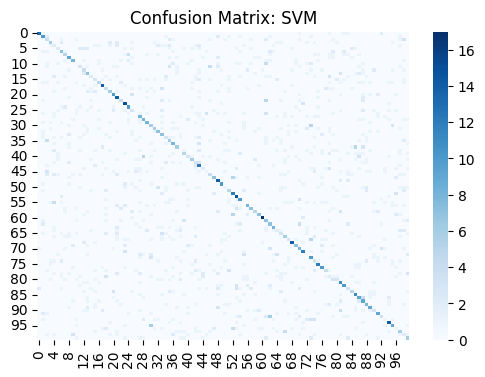

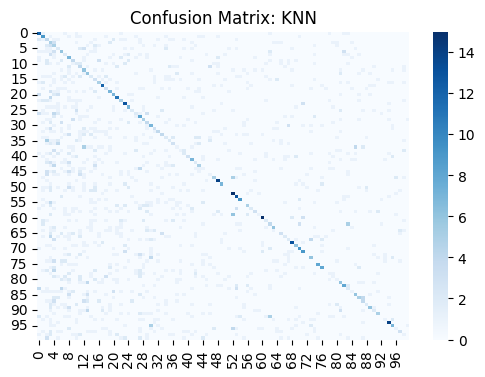

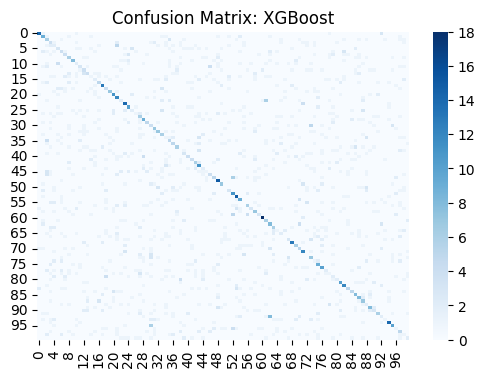


--- Classification Summary Table ---
  Model  Accuracy  Precision  Recall  F1-Score
    SVM    0.3235   0.315265  0.3235  0.311008
XGBoost    0.2805   0.263307  0.2805  0.263937
    KNN    0.2310   0.235205  0.2310  0.219772
KMeans Silhouette Score: 0.0808
DBSCAN: Silhouette Score not applicable
Agglomerative Silhouette Score: 0.0468

--- Clustering Summary Table ---
   Clustering  Silhouette Score
       KMeans          0.080824
Agglomerative          0.046813
       DBSCAN               NaN


In [ ]:

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, silhouette_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# 1. Data Preparation
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# 2. Model Definition and Training (SGD + L1 regularization)
class FeatureNet(nn.Module):
    def __init__(self):
        super(FeatureNet, self).__init__()
        self.model = models.resnet18(pretrained=False)
        self.model.fc = nn.Linear(self.model.fc.in_features, 100)

    def forward(self, x):
        return self.model(x)

def train_model():
    model = FeatureNet()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    l1_lambda = 1e-5

    model.train()
    for epoch in range(5):
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            l1_penalty = sum(p.abs().sum() for p in model.parameters())
            loss += l1_lambda * l1_penalty
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}: Loss = {running_loss:.4f}")
    return model

# 3. Feature Extraction and Dimensionality Reduction

def extract_features(model):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    features, labels = [], []
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs = inputs.to(device)
            x = model.model.conv1(inputs)
            x = model.model.bn1(x)
            x = model.model.relu(x)
            x = model.model.maxpool(x)
            x = model.model.layer1(x)
            x = model.model.layer2(x)
            x = model.model.layer3(x)
            x = model.model.layer4(x)
            x = model.model.avgpool(x)
            x = torch.flatten(x, 1)
            features.append(x.cpu().numpy())
            labels.extend(targets.numpy())
    features = np.vstack(features)
    pca = PCA(n_components=50)
    reduced = pca.fit_transform(features)
    tsne = TSNE(n_components=2, perplexity=30)
    tsne_feat = tsne.fit_transform(reduced)
    return reduced, np.array(labels), tsne_feat

# 4. Classification with ML Algorithms

def run_classifiers(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    classifiers = {
        'SVM': SVC(),
        'KNN': KNeighborsClassifier(),
        'XGBoost': RandomForestClassifier()
    }
    summary = []
    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')
        cm = confusion_matrix(y_test, y_pred)
        summary.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix: {name}")
        plt.show()
    print("\n--- Classification Summary Table ---")
    df = pd.DataFrame(summary)
    print(df.sort_values(by="F1-Score", ascending=False).to_string(index=False))

# 5. Clustering

def run_clustering(X, y):
    clustering_algos = {
        'KMeans': KMeans(n_clusters=10, random_state=42),
        'DBSCAN': DBSCAN(eps=5),
        'Agglomerative': AgglomerativeClustering(n_clusters=10)
    }
    summary = []
    for name, algo in clustering_algos.items():
        try:
            labels = algo.fit_predict(X)
            if len(set(labels)) > 1 and -1 not in labels:
                score = silhouette_score(X, labels)
                print(f"{name} Silhouette Score: {score:.4f}")
                summary.append({"Clustering": name, "Silhouette Score": score})
            else:
                print(f"{name}: Silhouette Score not applicable")
                summary.append({"Clustering": name, "Silhouette Score": None})
        except Exception as e:
            print(f"{name} failed: {e}")
            summary.append({"Clustering": name, "Silhouette Score": None})
    print("\n--- Clustering Summary Table ---")
    df = pd.DataFrame(summary)
    print(df.sort_values(by="Silhouette Score", ascending=False).to_string(index=False))

# 6. Main Execution
if __name__ == '__main__':
    model = train_model()
    features, labels, tsne_feat = extract_features(model)
    run_classifiers(features, labels)
    run_clustering(features, labels)
